## DepMap Sample Info (master catalogue) — `9_DepMap_sample_info.csv`

One row per cell line (1,840 total) with cancer type, tissue of origin, lineage, and cross-reference IDs. `DepMap_ID` here is identical to `ModelID` in all other DepMap files — it is the canonical key everything joins to. `RRID` holds the Cellosaurus accession (`CVCL_...`), linking DepMap into the broader cell line world.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
df = pd.read_csv(ini.df9)

In [3]:
df.shape

(1840, 29)

In [4]:
df.head()

,DepMap_ID,cell_line_name,stripped_cell_line_name,CCLE_Name,alias,COSMICID,sex,source,RRID,WTSI_Master_Cell_ID,...,lineage_sub_subtype,lineage_molecular_subtype,default_growth_pattern,model_manipulation,model_manipulation_details,patient_id,parent_depmap_id,Cellosaurus_NCIt_disease,Cellosaurus_NCIt_id,Cellosaurus_issues
0,ACH-000016,SLR 21,SLR21,SLR21_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_V607,NaN,...,NaN,NaN,NaN,NaN,NaN,PT-JnARLB,NaN,Clear cell renal cell carcinoma,C4033,NaN
1,ACH-000032,MHH-CALL-3,MHHCALL3,MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Female,DSMZ,CVCL_0089,NaN,...,b_cell,NaN,NaN,NaN,NaN,PT-p2KOyI,NaN,Childhood B acute lymphoblastic leukemia,C9140,NaN
2,ACH-000033,NCI-H1819,NCIH1819,NCIH1819_LUNG,NaN,NaN,Female,Academic lab,CVCL_1497,NaN,...,NSCLC_adenocarcinoma,NaN,NaN,NaN,NaN,PT-9p1WQv,NaN,Lung adenocarcinoma,C3512,NaN
3,ACH-000043,Hs 895.T,HS895T,HS895T_FIBROBLAST,NaN,NaN,Female,ATCC,CVCL_0993,NaN,...,NaN,NaN,2D: adherent,NaN,NaN,PT-rTUVZQ,NaN,Melanoma,C3224,NaN
4,ACH-000049,HEK TE,HEKTE,HEKTE_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_WS59,NaN,...,NaN,NaN,NaN,immortalized,NaN,PT-qWYYgr,NaN,NaN,NaN,No information is available about this cell li...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1840 entries, 0 to 1839
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   DepMap_ID                   1840 non-null   str    
 1   cell_line_name              1748 non-null   str    
 2   stripped_cell_line_name     1839 non-null   str    
 3   CCLE_Name                   1836 non-null   str    
 4   alias                       113 non-null    str    
 5   COSMICID                    981 non-null    float64
 6   sex                         1738 non-null   str    
 7   source                      1793 non-null   str    
 8   RRID                        1818 non-null   str    
 9   WTSI_Master_Cell_ID         980 non-null    float64
 10  sample_collection_site      1833 non-null   str    
 11  primary_or_metastasis       1198 non-null   str    
 12  primary_disease             1840 non-null   str    
 13  Subtype                     1696 non-null   

In [6]:
df.loc[0]

DepMap_ID                                          ACH-000016
cell_line_name                                         SLR 21
stripped_cell_line_name                                 SLR21
CCLE_Name                                        SLR21_KIDNEY
alias                                                     NaN
COSMICID                                                  NaN
sex                                                       NaN
source                                           Academic lab
RRID                                                CVCL_V607
WTSI_Master_Cell_ID                                       NaN
sample_collection_site                                 kidney
primary_or_metastasis                              Metastasis
primary_disease                                 Kidney Cancer
Subtype                                  Renal Cell Carcinoma
age                                                       NaN
Sanger_Model_ID                                           NaN
depmap_p

### Missing values
Columns with high missingness are candidates to drop before modelling.

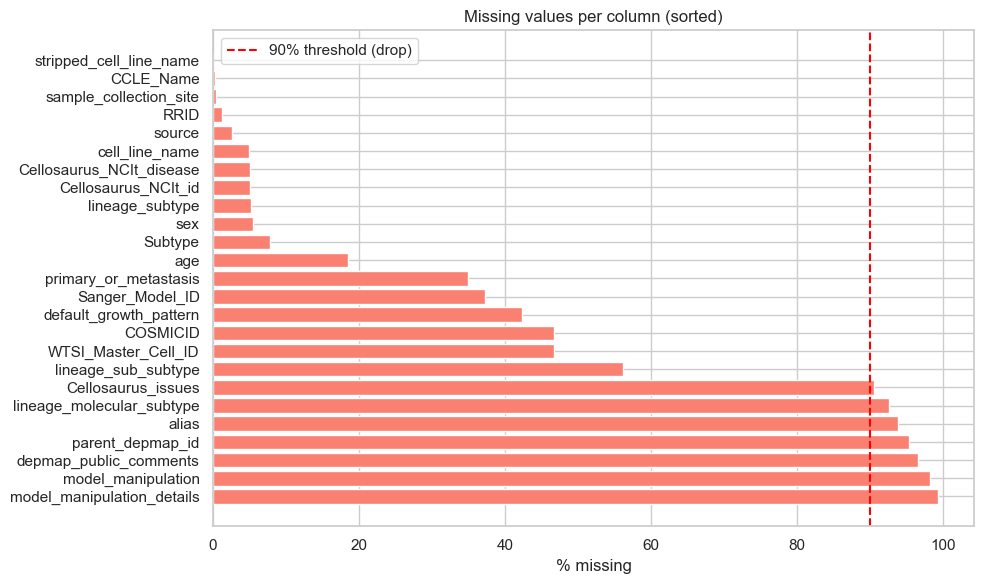

In [7]:
pct_missing = df.isnull().mean().sort_values(ascending=False) * 100
pct_missing = pct_missing[pct_missing > 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pct_missing.index, pct_missing.values, color="salmon")
ax.axvline(90, color="red", linestyle="--", label="90% threshold (drop)")
ax.set_xlabel("% missing"); ax.set_title("Missing values per column (sorted)")
ax.legend(); plt.tight_layout(); plt.show()


### Cancer type & tissue distribution
The most important chart: which cancer types are represented and how many cell lines per lineage.

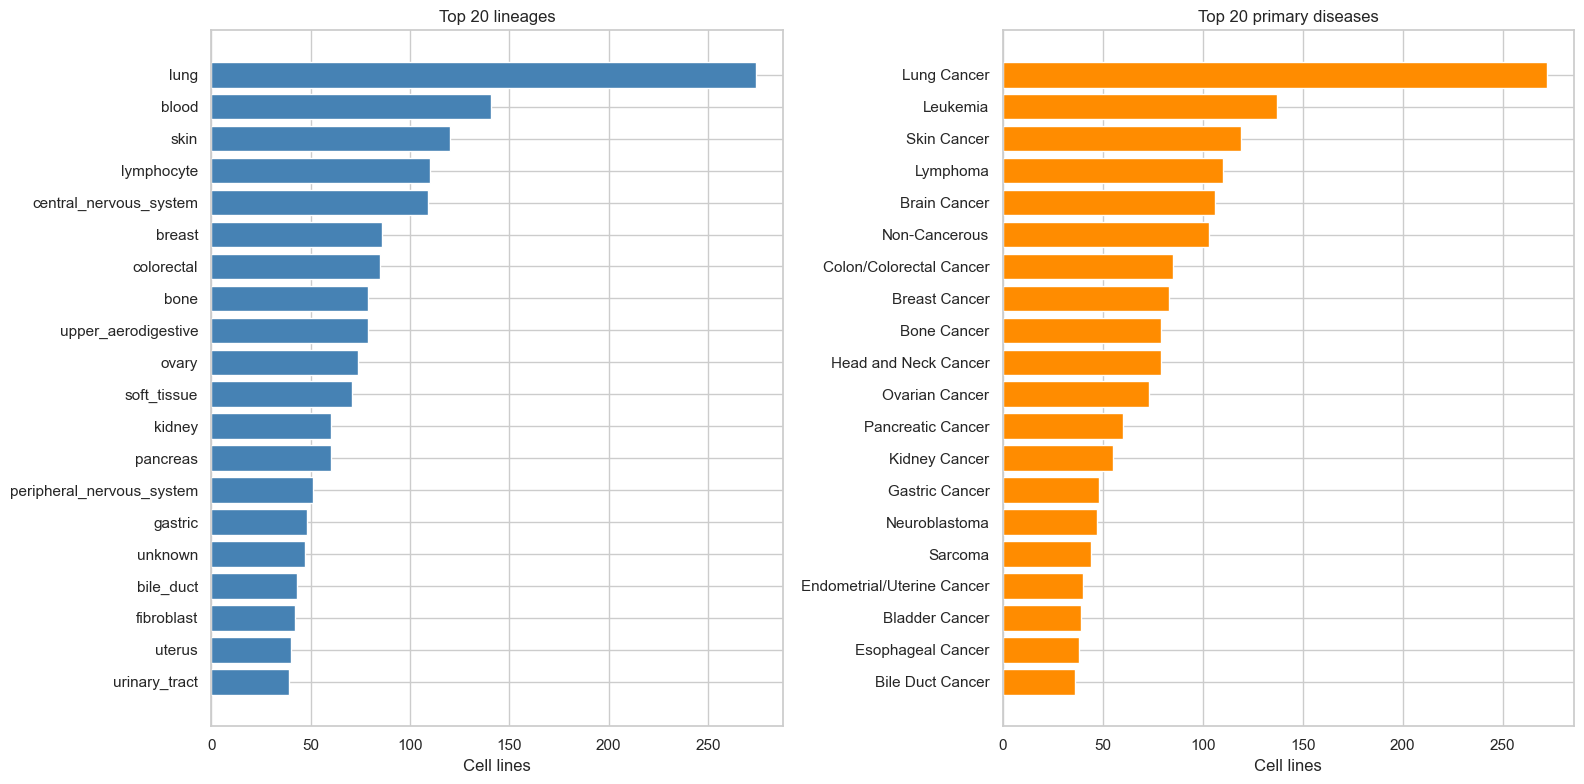

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_lineage = df["lineage"].value_counts().head(20)
axes[0].barh(top_lineage.index[::-1], top_lineage.values[::-1], color="steelblue")
axes[0].set_title("Top 20 lineages"); axes[0].set_xlabel("Cell lines")

top_disease = df["primary_disease"].value_counts().head(20)
axes[1].barh(top_disease.index[::-1], top_disease.values[::-1], color="darkorange")
axes[1].set_title("Top 20 primary diseases"); axes[1].set_xlabel("Cell lines")

plt.tight_layout(); plt.show()


### Clinical metadata: origin, sex, and growth pattern
These factors can confound drug-response comparisons if not accounted for.

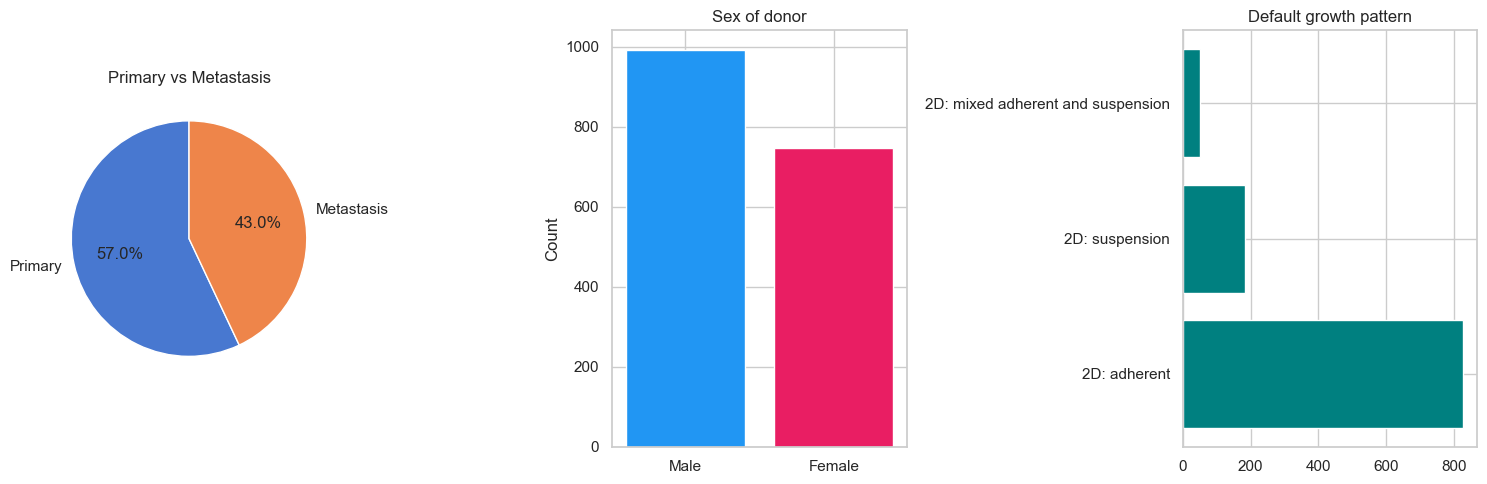

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Primary vs metastasis
pm = df["primary_or_metastasis"].value_counts()
axes[0].pie(pm.values, labels=pm.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Primary vs Metastasis")

# Sex
sex = df["sex"].value_counts()
axes[1].bar(sex.index, sex.values, color=["#2196F3", "#E91E63", "gray"])
axes[1].set_title("Sex of donor"); axes[1].set_ylabel("Count")

# Growth pattern
gp = df["default_growth_pattern"].value_counts()
axes[2].barh(gp.index, gp.values, color="teal")
axes[2].set_title("Default growth pattern")

plt.tight_layout(); plt.show()


### Cross-reference completeness
How many cell lines have IDs in external databases — important for data integration.

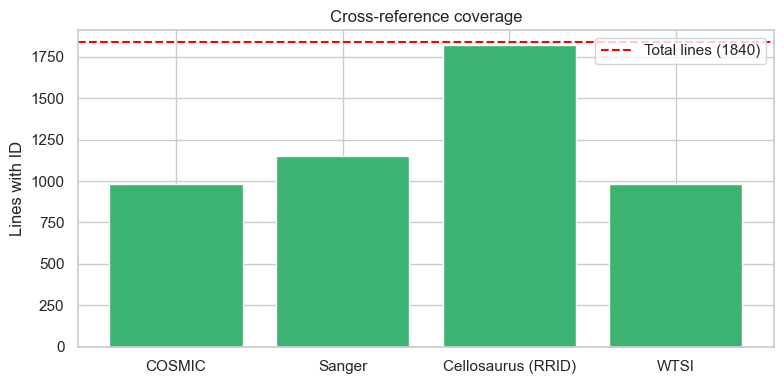

In [10]:
xref_cols = {"COSMICID": "COSMIC", "Sanger_Model_ID": "Sanger",
             "RRID": "Cellosaurus (RRID)", "WTSI_Master_Cell_ID": "WTSI"}
coverage = {label: df[col].notna().sum() for col, label in xref_cols.items()}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(coverage.keys(), coverage.values(), color="mediumseagreen")
ax.axhline(len(df), color="red", linestyle="--", label=f"Total lines ({len(df)})")
ax.set_title("Cross-reference coverage"); ax.set_ylabel("Lines with ID")
ax.legend(); plt.tight_layout(); plt.show()


### Key findings

In [11]:
print("=== DepMap Sample Info ===")
print(f"Total cell lines  : {len(df)}")
print(f"Unique lineages   : {df['lineage'].nunique()}")
print(f"Unique diseases   : {df['primary_disease'].nunique()}")
print(f"Has RRID (Cello.) : {df['RRID'].notna().sum()}")
print(f"Top lineage       : {df['lineage'].value_counts().idxmax()} ({df['lineage'].value_counts().max()} lines)")


=== DepMap Sample Info ===
Total cell lines  : 1840
Unique lineages   : 30
Unique diseases   : 33
Has RRID (Cello.) : 1818
Top lineage       : lung (274 lines)


## Join Analysis — df9 is the central hub

df9 is the master catalogue. Every other dataset ultimately joins TO df9.
The key question here is: **across all 13 other datasets, how many of df9's
1,840 cell lines are covered, and which cancer types are under-represented?**

| Other dataset | Join key (their side) | Join key (df9) | Notes |
|---|---|---|---|
| df2 (RNA) | ProfileID→ModelID via df8 | `DepMap_ID` | primary expression layer |
| df4 (Proteomics) | index (ACH-) | `DepMap_ID` | smallest coverage |
| df5 (Fusions) | `ModelID` | `DepMap_ID` | direct |
| df6 (Mutations) | ProfileID→ModelID via df8 | `DepMap_ID` | direct after bridge |
| df12 (Metabolomics) | `DepMap_ID` | `DepMap_ID` | direct |
| df14 (Genome sigs) | `ModelID` | `DepMap_ID` | direct |
| df7 (Cellosaurus) | `Accession` | `RRID` | name bridge |
| df1/df11 (HPA) | Cell line → CVCL_ → RRID | `RRID` | multi-hop |
| df3/df10 (GEO) | GSM → CVCL_ → RRID | `RRID` | multi-hop |
| df13 (miRNA) | CCLE_ID → DepMap_ID via df12 | `DepMap_ID` | via metabolomics |


In [12]:
# ── Coverage matrix: how many of df9's 1,840 lines does each dataset cover? ──
import warnings; warnings.filterwarnings("ignore")

df9_all = set(df["DepMap_ID"].dropna())
df8_tmp = pd.read_csv(ini.df8, usecols=["ProfileID","ModelID","Datatype"])

def rna_models():
    return set(df8_tmp[df8_tmp.Datatype=="rna"]["ModelID"])
def mut_models():
    pf = set(pd.read_csv(ini.df6, usecols=["ProfileID"],
                          low_memory=False)["ProfileID"].dropna())
    bridge = df8_tmp[df8_tmp.Datatype.isin(["wes","wgs"])]
    return set(bridge[bridge.ProfileID.isin(pf)]["ModelID"])

coverage = {
    "df2 RNA (DepMap)"    : rna_models() & df9_all,
    "df5 Fusions"         : set(pd.read_csv(ini.df5, usecols=["ModelID"])["ModelID"].dropna()) & df9_all,
    "df6 Mutations"       : mut_models() & df9_all,
    "df12 Metabolomics"   : set(pd.read_csv(ini.df12, usecols=["DepMap_ID"])["DepMap_ID"].dropna()) & df9_all,
    "df14 Genome sigs"    : set(pd.read_csv(ini.df14, usecols=["ModelID"])["ModelID"].dropna()) & df9_all,
    "df4 Proteomics"      : set(pd.read_csv(ini.df4, usecols=["Unnamed: 0"])["Unnamed: 0"].dropna()) & df9_all,
}

print(f"{'Dataset':<25} {'Lines covered':>14} {'% of df9':>10}")
print("-" * 52)
for name, ids in sorted(coverage.items(), key=lambda x: -len(x[1])):
    print(f"{name:<25} {len(ids):>14,} {len(ids)/len(df9_all)*100:>9.1f}%")


Dataset                    Lines covered   % of df9
----------------------------------------------------
df14 Genome sigs                   1,704      92.6%
df6 Mutations                      1,697      92.2%
df5 Fusions                        1,428      77.6%
df2 RNA (DepMap)                   1,412      76.7%
df12 Metabolomics                    927      50.4%
df4 Proteomics                       375      20.4%


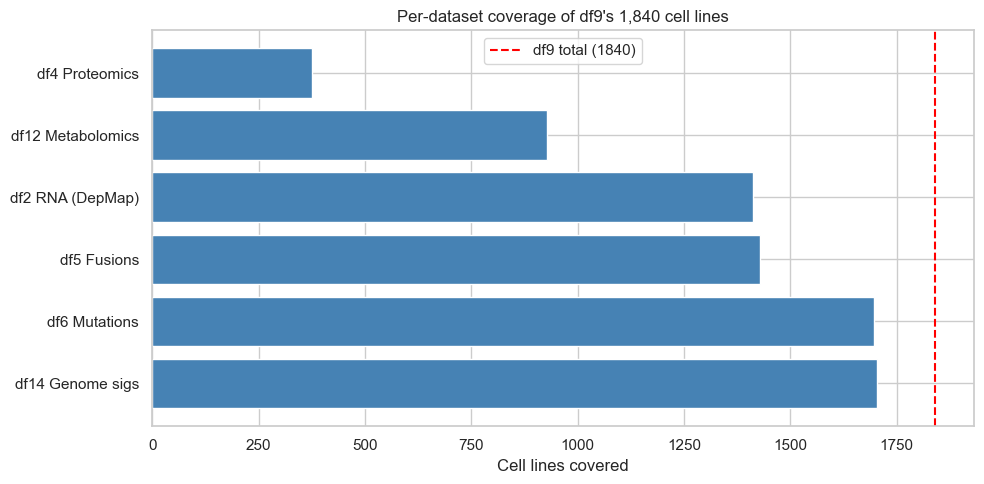

In [13]:
# Coverage bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(coverage.keys())
counts = [len(v) for v in coverage.values()]
order  = sorted(range(len(counts)), key=lambda i: -counts[i])
ax.barh([names[i] for i in order], [counts[i] for i in order], color="steelblue")
ax.axvline(len(df9_all), color="red", linestyle="--",
           label=f"df9 total ({len(df9_all)})")
ax.set_xlabel("Cell lines covered"); ax.legend()
ax.set_title("Per-dataset coverage of df9's 1,840 cell lines")
plt.tight_layout(); plt.show()


In [14]:
# ── C: Format check on df9 DepMap_ID ────────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["DepMap_ID"], "DepMap_ID (df9)", prefix="ACH-")
print()
fmt_check(df["RRID"].dropna(), "RRID (df9)", prefix="CVCL_")
print()
# Inconsistency check: RRID in df9 vs Accession in df7
df7_cvcl = set(pd.read_csv(ini.df7, usecols=["Accession (CVCL_xxxx)"])["Accession (CVCL_xxxx)"].dropna())
df9_rrid  = set(df["RRID"].dropna())
only_df9  = df9_rrid - df7_cvcl
only_df7  = df7_cvcl & df9_rrid  # just checking; large set
print(f"df9 RRID values not found in df7 CVCL_: {len(only_df9)}")
if only_df9:
    print(f"  Examples: {list(only_df9)[:5]}")


Format check — DepMap_ID (df9) (n=1840 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

Format check — RRID (df9) (n=1818 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 4



df9 RRID values not found in df7 CVCL_: 2
  Examples: ['CVCL_V618', 'CVCL_X507']


### Biological implications — which lineages are least covered across omics?

If a cancer lineage has high metadata coverage in df9 but low coverage in the omics
layers (df2, df5, df6, df14), that lineage will be poorly represented in any multi-omics
model. These lineages are at risk of being mis-predicted by the CellLineSelector because
the model has seen few examples of them during training.


In [15]:
# Per-lineage coverage across key omics layers
lineage_df9 = df[["DepMap_ID", "lineage"]].dropna()

for name, ids in [
    ("df2 RNA",       coverage["df2 RNA (DepMap)"]),
    ("df5 Fusions",   coverage["df5 Fusions"]),
    ("df6 Mutations", coverage["df6 Mutations"]),
    ("df14 GenomeSig",coverage["df14 Genome sigs"]),
]:
    lineage_df9[name] = lineage_df9["DepMap_ID"].isin(ids)

print("Coverage rate per lineage across four omics layers (% of that lineage covered):")
grp = lineage_df9.groupby("lineage")[["df2 RNA","df5 Fusions","df6 Mutations","df14 GenomeSig"]].mean() * 100
grp["mean_coverage"] = grp.mean(axis=1)
print(grp.sort_values("mean_coverage").head(10).round(1).to_string())
print()
print("Best-covered lineages (top 5):")
print(grp.sort_values("mean_coverage", ascending=False).head(5).round(1).to_string())


Coverage rate per lineage across four omics layers (% of that lineage covered):
                           df2 RNA  df5 Fusions  df6 Mutations  df14 GenomeSig  mean_coverage
lineage                                                                                      
unknown                        6.4          6.4           95.7            95.7           51.1
bone                          50.6         54.4           86.1            87.3           69.6
kidney                        65.0         65.0           86.7            86.7           75.8
breast                        73.3         74.4           79.1            79.1           76.5
fibroblast                    90.5         90.5           64.3            64.3           77.4
skin                          71.7         72.5           90.8            91.7           81.7
peripheral_nervous_system     68.6         70.6           98.0            98.0           83.8
upper_aerodigestive           72.2         73.4           94.9            

## Join Analysis — df9 is the central hub

df9 is the master catalogue. Every other dataset ultimately joins TO df9.
The key question here is: **across all 13 other datasets, how many of df9's
1,840 cell lines are covered, and which cancer types are under-represented?**

| Other dataset | Join key (their side) | Join key (df9) | Notes |
|---|---|---|---|
| df2 (RNA) | ProfileID→ModelID via df8 | `DepMap_ID` | primary expression layer |
| df4 (Proteomics) | index (ACH-) | `DepMap_ID` | smallest coverage |
| df5 (Fusions) | `ModelID` | `DepMap_ID` | direct |
| df6 (Mutations) | ProfileID→ModelID via df8 | `DepMap_ID` | direct after bridge |
| df12 (Metabolomics) | `DepMap_ID` | `DepMap_ID` | direct |
| df14 (Genome sigs) | `ModelID` | `DepMap_ID` | direct |
| df7 (Cellosaurus) | `Accession` | `RRID` | name bridge |
| df1/df11 (HPA) | Cell line → CVCL_ → RRID | `RRID` | multi-hop |
| df3/df10 (GEO) | GSM → CVCL_ → RRID | `RRID` | multi-hop |
| df13 (miRNA) | CCLE_ID → DepMap_ID via df12 | `DepMap_ID` | via metabolomics |


In [16]:
# ── Coverage matrix: how many of df9's 1,840 lines does each dataset cover? ──
import warnings; warnings.filterwarnings("ignore")

df9_all = set(df["DepMap_ID"].dropna())
df8_tmp = pd.read_csv(ini.df8, usecols=["ProfileID","ModelID","Datatype"])

def rna_models():
    return set(df8_tmp[df8_tmp.Datatype=="rna"]["ModelID"])
def mut_models():
    pf = set(pd.read_csv(ini.df6, usecols=["ProfileID"],
                          low_memory=False)["ProfileID"].dropna())
    bridge = df8_tmp[df8_tmp.Datatype.isin(["wes","wgs"])]
    return set(bridge[bridge.ProfileID.isin(pf)]["ModelID"])

coverage = {
    "df2 RNA (DepMap)"    : rna_models() & df9_all,
    "df5 Fusions"         : set(pd.read_csv(ini.df5, usecols=["ModelID"])["ModelID"].dropna()) & df9_all,
    "df6 Mutations"       : mut_models() & df9_all,
    "df12 Metabolomics"   : set(pd.read_csv(ini.df12, usecols=["DepMap_ID"])["DepMap_ID"].dropna()) & df9_all,
    "df14 Genome sigs"    : set(pd.read_csv(ini.df14, usecols=["ModelID"])["ModelID"].dropna()) & df9_all,
    "df4 Proteomics"      : set(pd.read_csv(ini.df4, usecols=["Unnamed: 0"])["Unnamed: 0"].dropna()) & df9_all,
}

print(f"{'Dataset':<25} {'Lines covered':>14} {'% of df9':>10}")
print("-" * 52)
for name, ids in sorted(coverage.items(), key=lambda x: -len(x[1])):
    print(f"{name:<25} {len(ids):>14,} {len(ids)/len(df9_all)*100:>9.1f}%")


Dataset                    Lines covered   % of df9
----------------------------------------------------
df14 Genome sigs                   1,704      92.6%
df6 Mutations                      1,697      92.2%
df5 Fusions                        1,428      77.6%
df2 RNA (DepMap)                   1,412      76.7%
df12 Metabolomics                    927      50.4%
df4 Proteomics                       375      20.4%


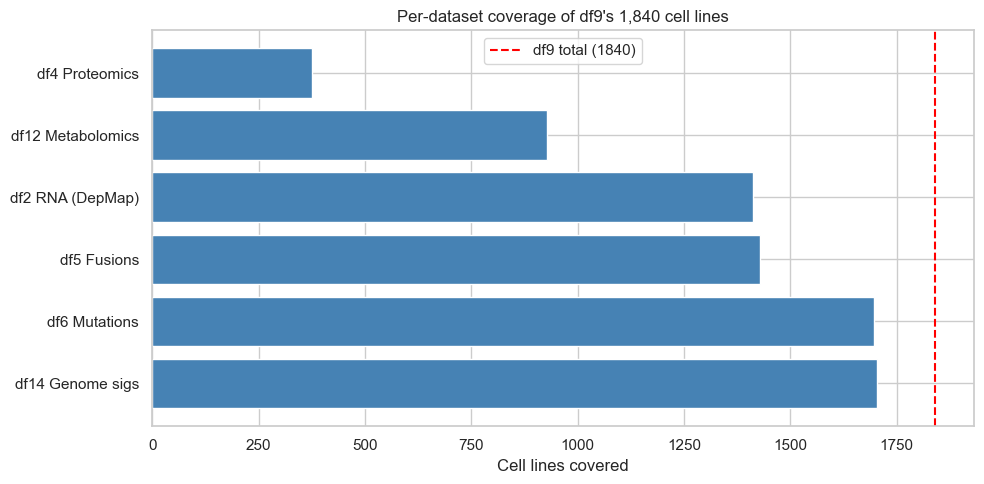

In [17]:
# Coverage bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(coverage.keys())
counts = [len(v) for v in coverage.values()]
order  = sorted(range(len(counts)), key=lambda i: -counts[i])
ax.barh([names[i] for i in order], [counts[i] for i in order], color="steelblue")
ax.axvline(len(df9_all), color="red", linestyle="--",
           label=f"df9 total ({len(df9_all)})")
ax.set_xlabel("Cell lines covered"); ax.legend()
ax.set_title("Per-dataset coverage of df9's 1,840 cell lines")
plt.tight_layout(); plt.show()


In [18]:
# ── C: Format check on df9 DepMap_ID ────────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["DepMap_ID"], "DepMap_ID (df9)", prefix="ACH-")
print()
fmt_check(df["RRID"].dropna(), "RRID (df9)", prefix="CVCL_")
print()
# Inconsistency check: RRID in df9 vs Accession in df7
df7_cvcl = set(pd.read_csv(ini.df7, usecols=["Accession (CVCL_xxxx)"])["Accession (CVCL_xxxx)"].dropna())
df9_rrid  = set(df["RRID"].dropna())
only_df9  = df9_rrid - df7_cvcl
only_df7  = df7_cvcl & df9_rrid  # just checking; large set
print(f"df9 RRID values not found in df7 CVCL_: {len(only_df9)}")
if only_df9:
    print(f"  Examples: {list(only_df9)[:5]}")


Format check — DepMap_ID (df9) (n=1840 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

Format check — RRID (df9) (n=1818 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 4



df9 RRID values not found in df7 CVCL_: 2
  Examples: ['CVCL_V618', 'CVCL_X507']


### Biological implications — which lineages are least covered across omics?

If a cancer lineage has high metadata coverage in df9 but low coverage in the omics
layers (df2, df5, df6, df14), that lineage will be poorly represented in any multi-omics
model. These lineages are at risk of being mis-predicted by the CellLineSelector because
the model has seen few examples of them during training.


In [19]:
# Per-lineage coverage across key omics layers
lineage_df9 = df[["DepMap_ID", "lineage"]].dropna()

for name, ids in [
    ("df2 RNA",       coverage["df2 RNA (DepMap)"]),
    ("df5 Fusions",   coverage["df5 Fusions"]),
    ("df6 Mutations", coverage["df6 Mutations"]),
    ("df14 GenomeSig",coverage["df14 Genome sigs"]),
]:
    lineage_df9[name] = lineage_df9["DepMap_ID"].isin(ids)

print("Coverage rate per lineage across four omics layers (% of that lineage covered):")
grp = lineage_df9.groupby("lineage")[["df2 RNA","df5 Fusions","df6 Mutations","df14 GenomeSig"]].mean() * 100
grp["mean_coverage"] = grp.mean(axis=1)
print(grp.sort_values("mean_coverage").head(10).round(1).to_string())
print()
print("Best-covered lineages (top 5):")
print(grp.sort_values("mean_coverage", ascending=False).head(5).round(1).to_string())


Coverage rate per lineage across four omics layers (% of that lineage covered):
                           df2 RNA  df5 Fusions  df6 Mutations  df14 GenomeSig  mean_coverage
lineage                                                                                      
unknown                        6.4          6.4           95.7            95.7           51.1
bone                          50.6         54.4           86.1            87.3           69.6
kidney                        65.0         65.0           86.7            86.7           75.8
breast                        73.3         74.4           79.1            79.1           76.5
fibroblast                    90.5         90.5           64.3            64.3           77.4
skin                          71.7         72.5           90.8            91.7           81.7
peripheral_nervous_system     68.6         70.6           98.0            98.0           83.8
upper_aerodigestive           72.2         73.4           94.9            

## Deeper dive: actionable drop / impute column list

Turning the missingness chart into an explicit preprocessing decision: columns >90%
missing are drop candidates; 5-90% missing are impute/flag candidates; the rest are kept.

In [20]:
miss = df.isna().mean().sort_values(ascending=False)
drop   = miss[miss > 0.90].index.tolist()
impute = miss[(miss > 0.05) & (miss <= 0.90)].index.tolist()
keep   = miss[miss <= 0.05].index.tolist()
print("DROP   (>90% missing):", drop)
print("\nIMPUTE/FLAG (5-90%) :", impute)
print("\nKEEP   (<=5% missing):", len(keep), "columns incl.",
      [c for c in ['DepMap_ID','cell_line_name','lineage','primary_disease'] if c in keep])

DROP   (>90% missing): ['model_manipulation_details', 'model_manipulation', 'depmap_public_comments', 'parent_depmap_id', 'alias', 'lineage_molecular_subtype', 'Cellosaurus_issues']

IMPUTE/FLAG (5-90%) : ['lineage_sub_subtype', 'WTSI_Master_Cell_ID', 'COSMICID', 'default_growth_pattern', 'Sanger_Model_ID', 'primary_or_metastasis', 'age', 'Subtype', 'sex', 'lineage_subtype', 'Cellosaurus_NCIt_id', 'Cellosaurus_NCIt_disease']

KEEP   (<=5% missing): 10 columns incl. ['DepMap_ID', 'cell_line_name', 'lineage', 'primary_disease']


## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
This is the **master patient chart for every cell line** — the central registry. For each of the **1,840 cell lines** it records the essentials: what cancer it is, what tissue it came from, the patient's sex, growth behaviour, and all its cross-reference IDs. Crucially, its `DepMap_ID` is the **one ID that every other dataset ultimately joins onto** — it's the spine of the whole project.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **1,840 cell lines × 29 columns**, keyed by `DepMap_ID` (the canonical cell-line ID).
- **30 tissue lineages, 33 disease types**; lung is the biggest group (274 lines).
- Many metadata columns are **half-empty**; the notebook sorted them into **drop / impute / keep** buckets (7 columns >90% empty → drop; 12 partly empty → impute-or-flag; 10 well-filled → keep).
- The fields `lineage` and `primary_disease` are the **labels and filter fields** the system will use.

Next steps (preprocessing):
- **Treat `DepMap_ID` as the canonical key** that all measurement layers attach to.
- **Drop the 7 mostly-empty columns; impute-or-flag the 12 middling ones; keep the 10 solid ones.**
- **Expose `lineage` / `primary_disease` (and similar) as the frontend filter facets** so researchers can narrow results.

Still missing in EDA:
- **Define the actual target/label for ranking** from these fields — i.e., decide what "a good cell line for this request" means in terms the model can be scored against.

### 3. Which ML approach fits this dataset
**This file supplies the labels and the filter facets, not the measurement features.** It's where any **supervised target** would live (e.g., the lineage/disease a researcher filters to), and it powers the frontend filtering the project calls for. The measurement files provide the *inputs*; this provides the *answer key and the filters*.

> **Big-picture note:** This is the **spine**. Everything — RNA, proteins, mutations, fusions, metabolites, miRNA, genome scores — joins onto `DepMap_ID` here. The ~1,400 lines that have the core measurement layers all live in this catalogue.